# House Price Prediction — Larsen & Toubro Realty
### MST Mini Project (UCS321) — Regression
**Goal:** Predict house prices from location, size, rooms and other attributes, and find the most influential features.

**Dataset:** California Housing Prices (same data as the Kaggle "California Housing Prices" dataset), 20,640 rows.
Target: `median_house_value` (in $).

**Workflow:** Load → Inspect → EDA → Clean → Pre-process → Models → Evaluate → Tune → Feature importance → Save model

## 1. Import Libraries

In [1]:
import numpy as np, pandas as pd, joblib, json
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
sns.set_style("whitegrid"); plt.rcParams["figure.figsize"] = (8, 5)

## 2. Load Dataset

In [2]:
df = pd.read_csv("housing.csv")
print(df.shape)
df.head()

(20640, 10)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


## 3. Inspect the Data

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


In [4]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [5]:
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

## 4. Exploratory Data Analysis

### 4.1 Price distribution
Note the spike at $500,001 — the target is capped in the original data.

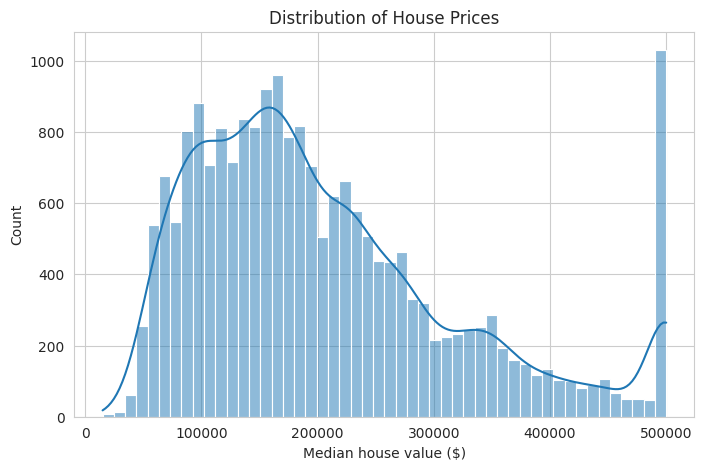

In [6]:
sns.histplot(df["median_house_value"], bins=50, kde=True)
plt.title("Distribution of House Prices"); plt.xlabel("Median house value ($)"); plt.show()

### 4.2 Correlation heatmap

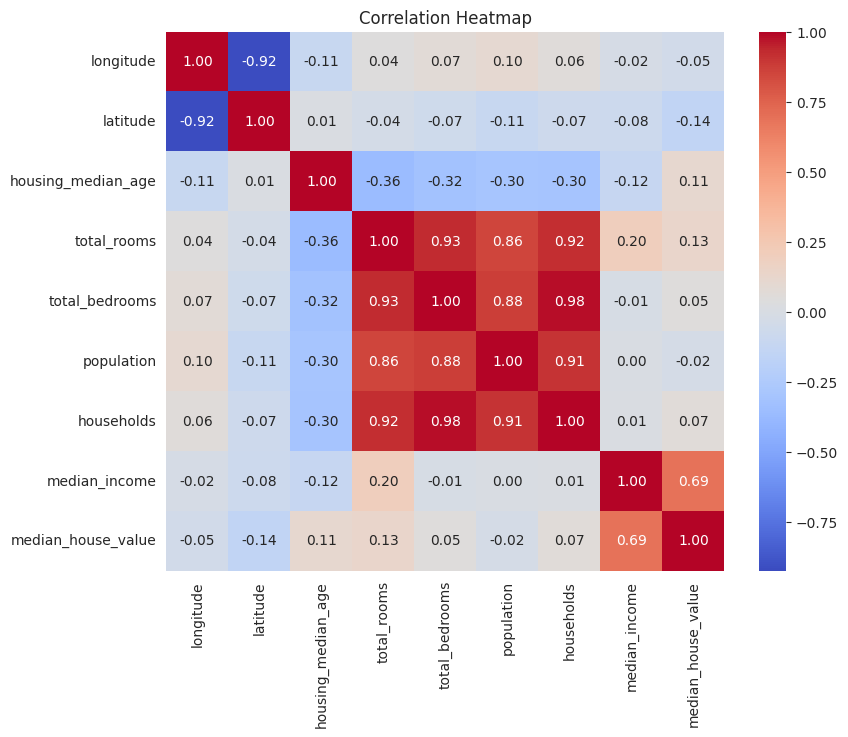

In [7]:
plt.figure(figsize=(9, 7))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap"); plt.show()

### 4.3 Feature vs price

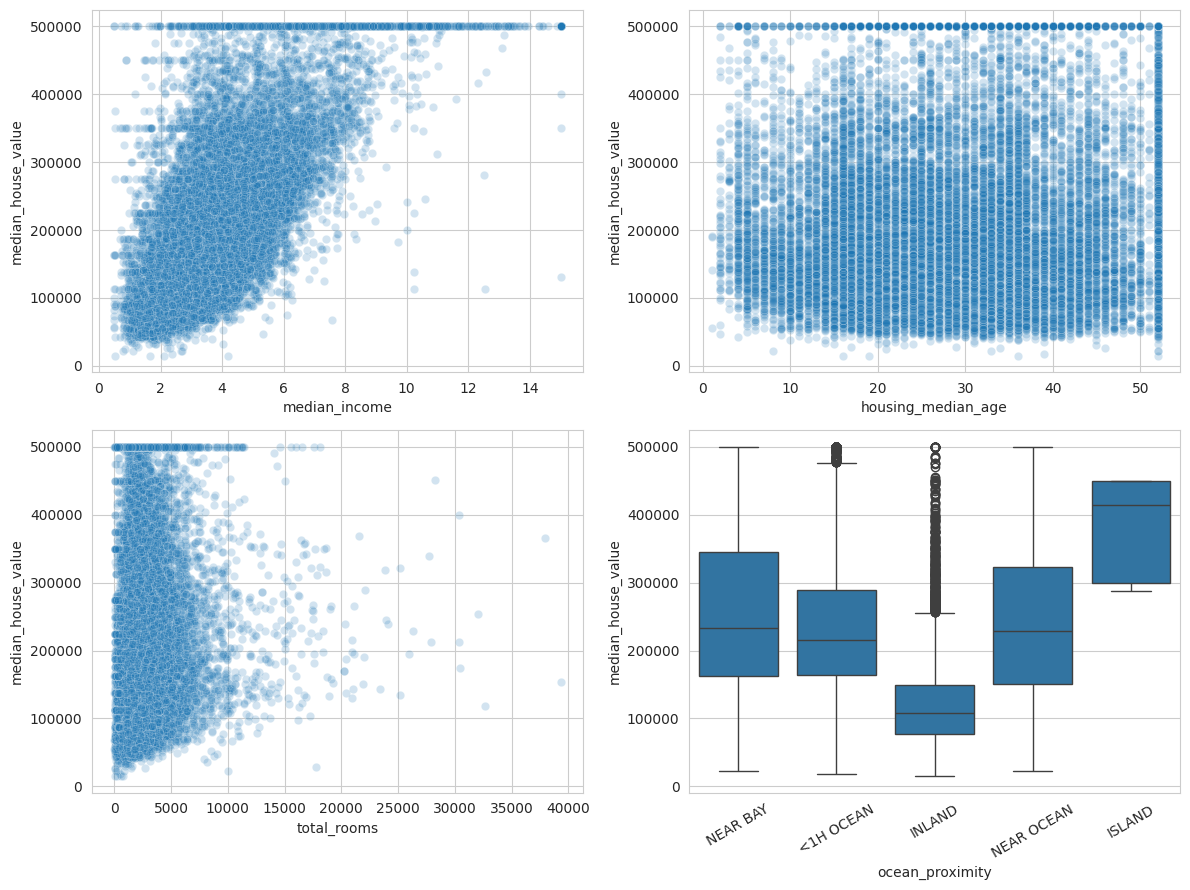

In [8]:
fig, ax = plt.subplots(2, 2, figsize=(12, 9))
sns.scatterplot(data=df, x="median_income", y="median_house_value", alpha=0.2, ax=ax[0,0])
sns.scatterplot(data=df, x="housing_median_age", y="median_house_value", alpha=0.2, ax=ax[0,1])
sns.scatterplot(data=df, x="total_rooms", y="median_house_value", alpha=0.2, ax=ax[1,0])
sns.boxplot(data=df, x="ocean_proximity", y="median_house_value", ax=ax[1,1])
ax[1,1].tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.show()

### 4.4 Geographic view (location effect)

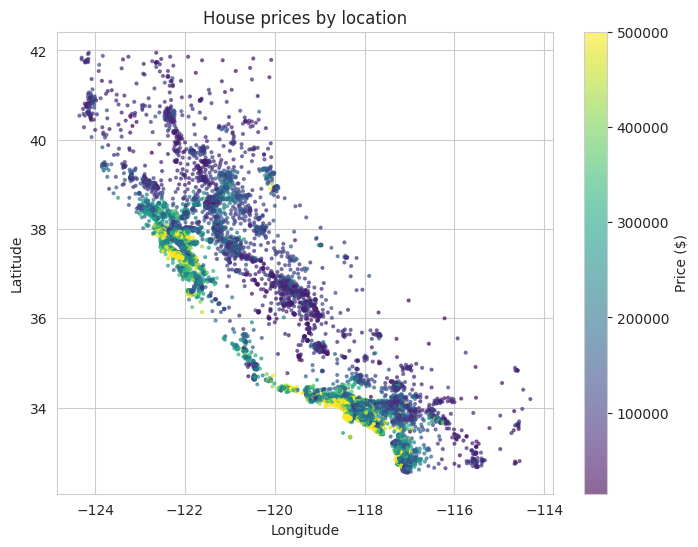

In [9]:
plt.figure(figsize=(8, 6))
sc = plt.scatter(df.longitude, df.latitude, c=df.median_house_value, cmap="viridis", s=4, alpha=0.6)
plt.colorbar(sc, label="Price ($)"); plt.xlabel("Longitude"); plt.ylabel("Latitude")
plt.title("House prices by location"); plt.show()

## 5. Cleaning & Feature Engineering
- Fill missing `total_bedrooms` with the median
- Remove rows where price is capped at $500,001 (artificial ceiling that distorts learning)
- Create ratio features: rooms per household, bedrooms per room, people per household

In [10]:
df["total_bedrooms"] = df["total_bedrooms"].fillna(df["total_bedrooms"].median())
print("Rows before:", len(df))
df = df[df["median_house_value"] < 500001].copy()
print("Rows after removing capped prices:", len(df))

df["rooms_per_household"] = df["total_rooms"] / df["households"]
df["bedrooms_per_room"] = df["total_bedrooms"] / df["total_rooms"]
df["people_per_household"] = df["population"] / df["households"]
df.isnull().sum().sum()

Rows before: 20640
Rows after removing capped prices: 19675


np.int64(0)

## 6. Pre-processing
One-hot encode `ocean_proximity`, split 80/20, scale for Linear Regression.

In [11]:
df_enc = pd.get_dummies(df, columns=["ocean_proximity"], drop_first=True)
X = df_enc.drop(columns=["median_house_value"])
y = df_enc["median_house_value"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train); X_test_s = scaler.transform(X_test)
print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (15740, 15) Test: (3935, 15)


## 7. Baseline — Linear Regression
## 8. Evaluation metrics: RMSE, MAE, R²

In [12]:
def evaluate(y_true, y_pred, name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred); r2 = r2_score(y_true, y_pred)
    print(f"--- {name} ---\nRMSE: {rmse:,.0f}\nMAE:  {mae:,.0f}\nR2:   {r2:.4f}\n")
    return {"Model": name, "RMSE": rmse, "MAE": mae, "R2": r2}

results = []
lr = LinearRegression().fit(X_train_s, y_train)
pred_lr = lr.predict(X_test_s)
results.append(evaluate(y_test, pred_lr, "Linear Regression"))

--- Linear Regression ---
RMSE: 62,205
MAE:  45,480
R2:   0.6119



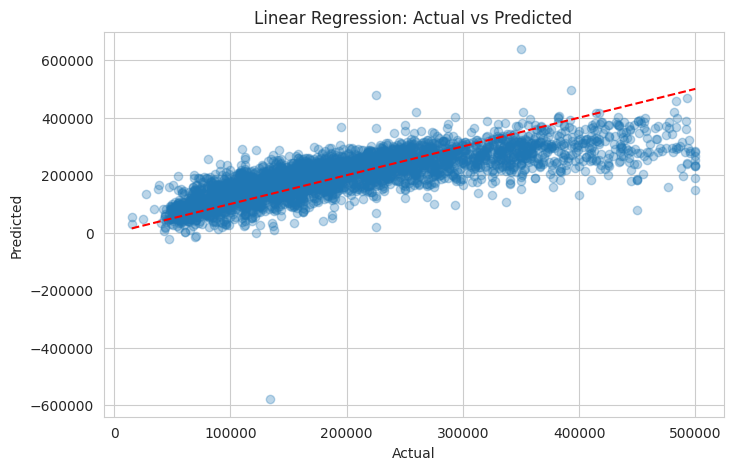

In [13]:
plt.scatter(y_test, pred_lr, alpha=0.3)
plt.plot([y.min(), y.max()], [y.min(), y.max()], "r--")
plt.xlabel("Actual"); plt.ylabel("Predicted"); plt.title("Linear Regression: Actual vs Predicted"); plt.show()

## 9. Random Forest Regressor

In [14]:
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1).fit(X_train, y_train)
pred_rf = rf.predict(X_test)
results.append(evaluate(y_test, pred_rf, "Random Forest"))

--- Random Forest ---
RMSE: 46,305
MAE:  30,814
R2:   0.7850



### 9.1 Hyperparameter tuning (GridSearchCV)

In [15]:
param_grid = {"n_estimators": [100], "max_depth": [20, None], "min_samples_split": [2, 5]}
gs = GridSearchCV(RandomForestRegressor(random_state=42, n_jobs=-1), param_grid, cv=3, scoring="r2", n_jobs=-1)
gs.fit(X_train, y_train)
print("Best params:", gs.best_params_)
best_rf = gs.best_estimator_
pred_best = best_rf.predict(X_test)
results.append(evaluate(y_test, pred_best, "Random Forest (Tuned)"))

Best params: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 100}
--- Random Forest (Tuned) ---
RMSE: 46,307
MAE:  30,821
R2:   0.7849



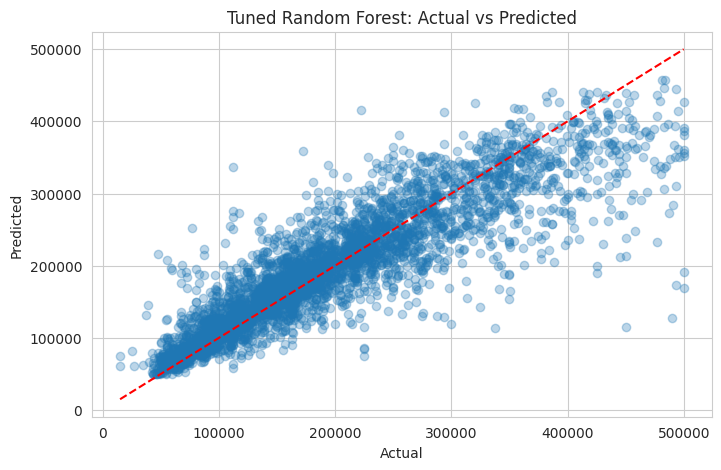

In [16]:
plt.scatter(y_test, pred_best, alpha=0.3)
plt.plot([y.min(), y.max()], [y.min(), y.max()], "r--")
plt.xlabel("Actual"); plt.ylabel("Predicted"); plt.title("Tuned Random Forest: Actual vs Predicted"); plt.show()

## 10. Feature Importance
Which factors influence price the most?

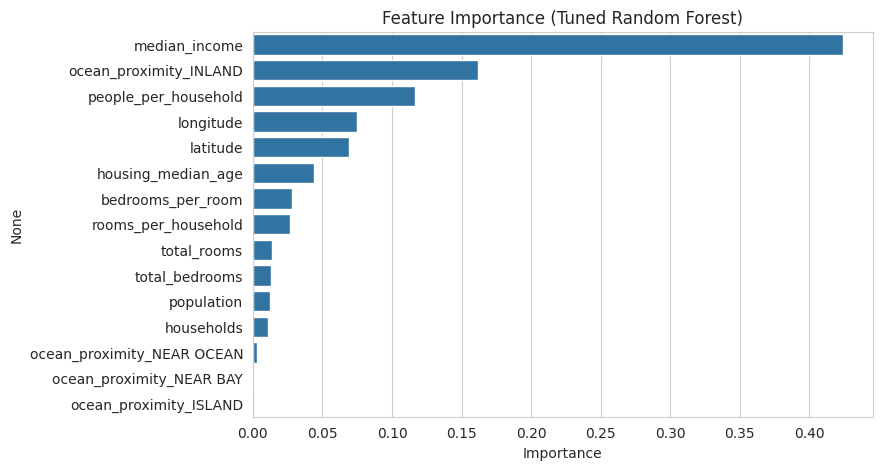

median_income                 0.4245
ocean_proximity_INLAND        0.1619
people_per_household          0.1168
longitude                     0.0748
latitude                      0.0689
housing_median_age            0.0437
bedrooms_per_room             0.0284
rooms_per_household           0.0270
total_rooms                   0.0140
total_bedrooms                0.0127
population                    0.0122
households                    0.0110
ocean_proximity_NEAR OCEAN    0.0031
ocean_proximity_NEAR BAY      0.0010
ocean_proximity_ISLAND        0.0002
dtype: float64

In [17]:
imp = pd.Series(best_rf.feature_importances_, index=X.columns).sort_values(ascending=False)
sns.barplot(x=imp.values, y=imp.index); plt.title("Feature Importance (Tuned Random Forest)"); plt.xlabel("Importance"); plt.show()
imp.round(4)

## 11. Model Comparison

In [18]:
results_df = pd.DataFrame(results).round(4)
results_df

,Model,RMSE,MAE,R2
0,Linear Regression,62204.6484,45479.8891,0.6119
1,Random Forest,46305.1526,30813.9608,0.7850
2,Random Forest (Tuned),46307.0789,30820.6581,0.7849


## 12. Save Model for the Web App

In [19]:
joblib.dump(best_rf, "model.joblib")
meta = {"columns": list(X.columns),
        "ocean_options": sorted(df["ocean_proximity"].unique().tolist()),
        "defaults": {c: float(X[c].median()) for c in X.columns},
        "metrics": results_df.to_dict(orient="records")}
json.dump(meta, open("meta.json", "w"), indent=2)
print("Saved model.joblib and meta.json")

Saved model.joblib and meta.json


## 13. Conclusion
- Dataset: California Housing (20,640 rows; 19,675 after removing capped $500,001 prices).
- **Linear Regression (baseline):** RMSE ≈ $62,205, MAE ≈ $45,480, R² = 0.612.
- **Random Forest:** RMSE ≈ $46,305, MAE ≈ $30,814, R² = 0.785 — a clear improvement, because it captures non-linear patterns (e.g. location x income).
- **Tuned Random Forest:** R² = 0.785, essentially identical to the default forest, so tuning gave no real gain here; the default settings were already near-optimal for this grid.
- **Most influential features:** `median_income` (~42%), then `ocean_proximity_INLAND` (~16%), `people_per_household` (~12%), and location (`longitude`/`latitude`, ~7% each).
- **Limitation:** each row is a block-group average, not a single house, and prices are in 1990 dollars; predictions are estimates for a neighbourhood, not an individual property.
- **Future work:** try Gradient Boosting / XGBoost, add more engineered features (distance to major cities).